<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/2.heart_diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
!pip install optuna

In [152]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score,StratifiedKFold

import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek


In [153]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GPU Available: True
Device Name: Tesla T4
Device: cuda


In [154]:
df=pd.read_csv("/content/heart_disease_uci.csv")

**EDA**

In [155]:
df.sample(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
846,847,54,Female,VA Long Beach,asymptomatic,138.0,274.0,False,normal,105.0,True,1.5,flat,NaN,NaN,1
264,265,61,Male,Cleveland,asymptomatic,138.0,166.0,False,lv hypertrophy,125.0,True,3.6,flat,1.0,normal,4
845,846,76,Male,VA Long Beach,non-anginal,104.0,NaN,False,lv hypertrophy,120.0,False,3.5,downsloping,NaN,NaN,4
405,406,49,Female,Hungary,atypical angina,110.0,NaN,False,normal,160.0,False,0.0,NaN,NaN,NaN,0
887,888,69,Male,VA Long Beach,non-anginal,NaN,271.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [156]:
df.shape

(920, 16)

In [157]:
df.drop(columns=["id"],inplace=True)

In [158]:
df.sample(5)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
822,48,Male,VA Long Beach,non-anginal,102.0,0.0,NaN,st-t abnormality,110.0,True,1.0,downsloping,NaN,NaN,1
335,39,Male,Hungary,atypical angina,120.0,200.0,False,normal,160.0,True,1.0,flat,NaN,NaN,0
864,54,Male,VA Long Beach,non-anginal,NaN,203.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
205,45,Male,Cleveland,asymptomatic,142.0,309.0,False,lv hypertrophy,147.0,True,0.0,flat,3.0,reversable defect,3
124,65,Male,Cleveland,typical angina,138.0,282.0,True,lv hypertrophy,174.0,False,1.4,flat,1.0,normal,1


In [159]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [160]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55


In [161]:
df.duplicated().sum()

np.int64(2)

In [162]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [163]:
numeric_cols=df.select_dtypes(include=[np.number])


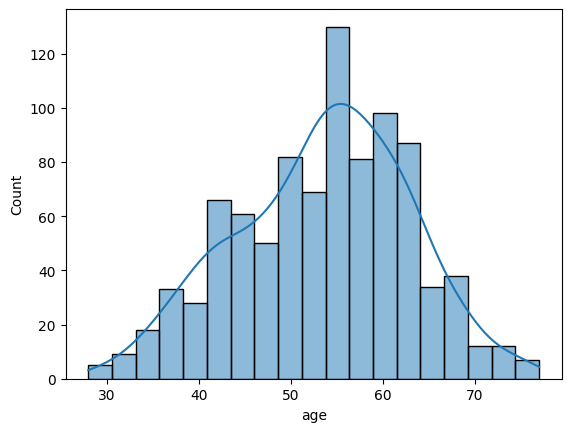

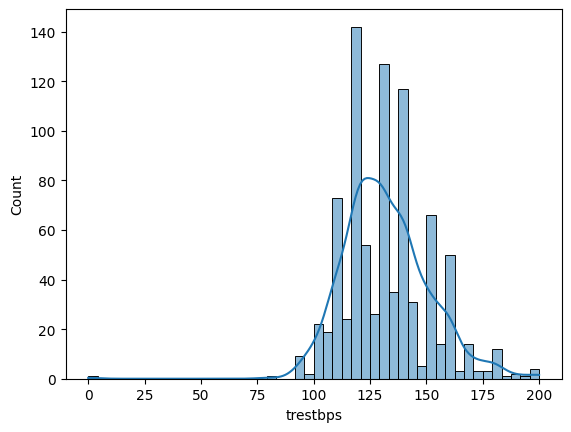

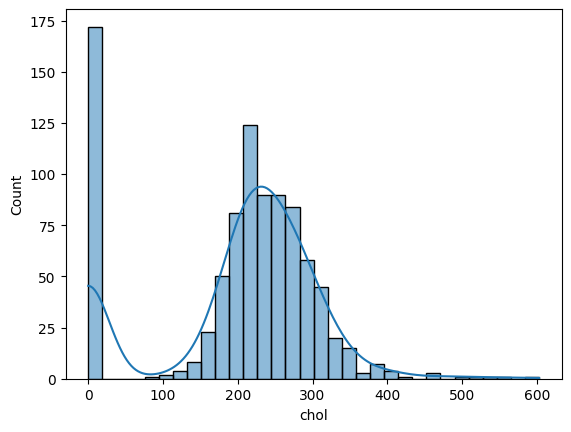

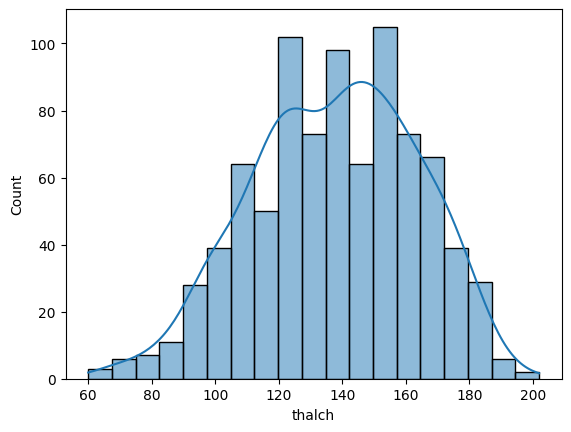

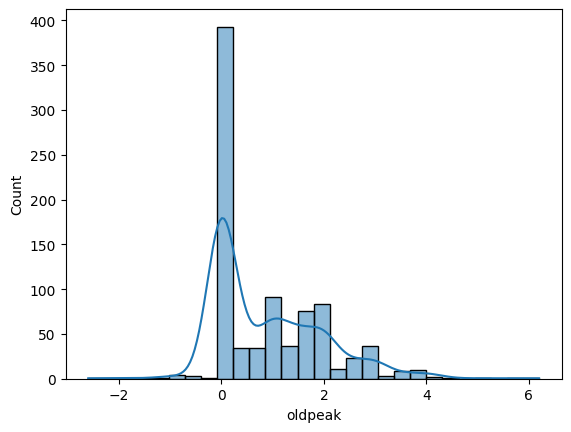

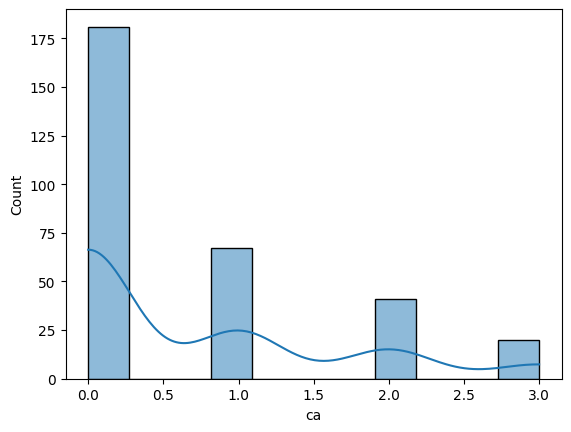

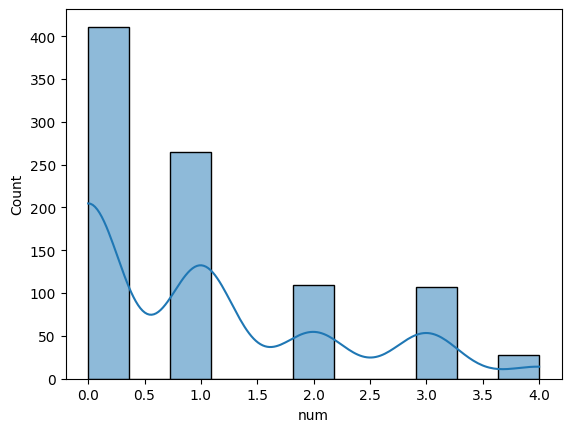

In [164]:

for col in numeric_cols:
  sns.histplot(df[col],kde=True)
  plt.show()


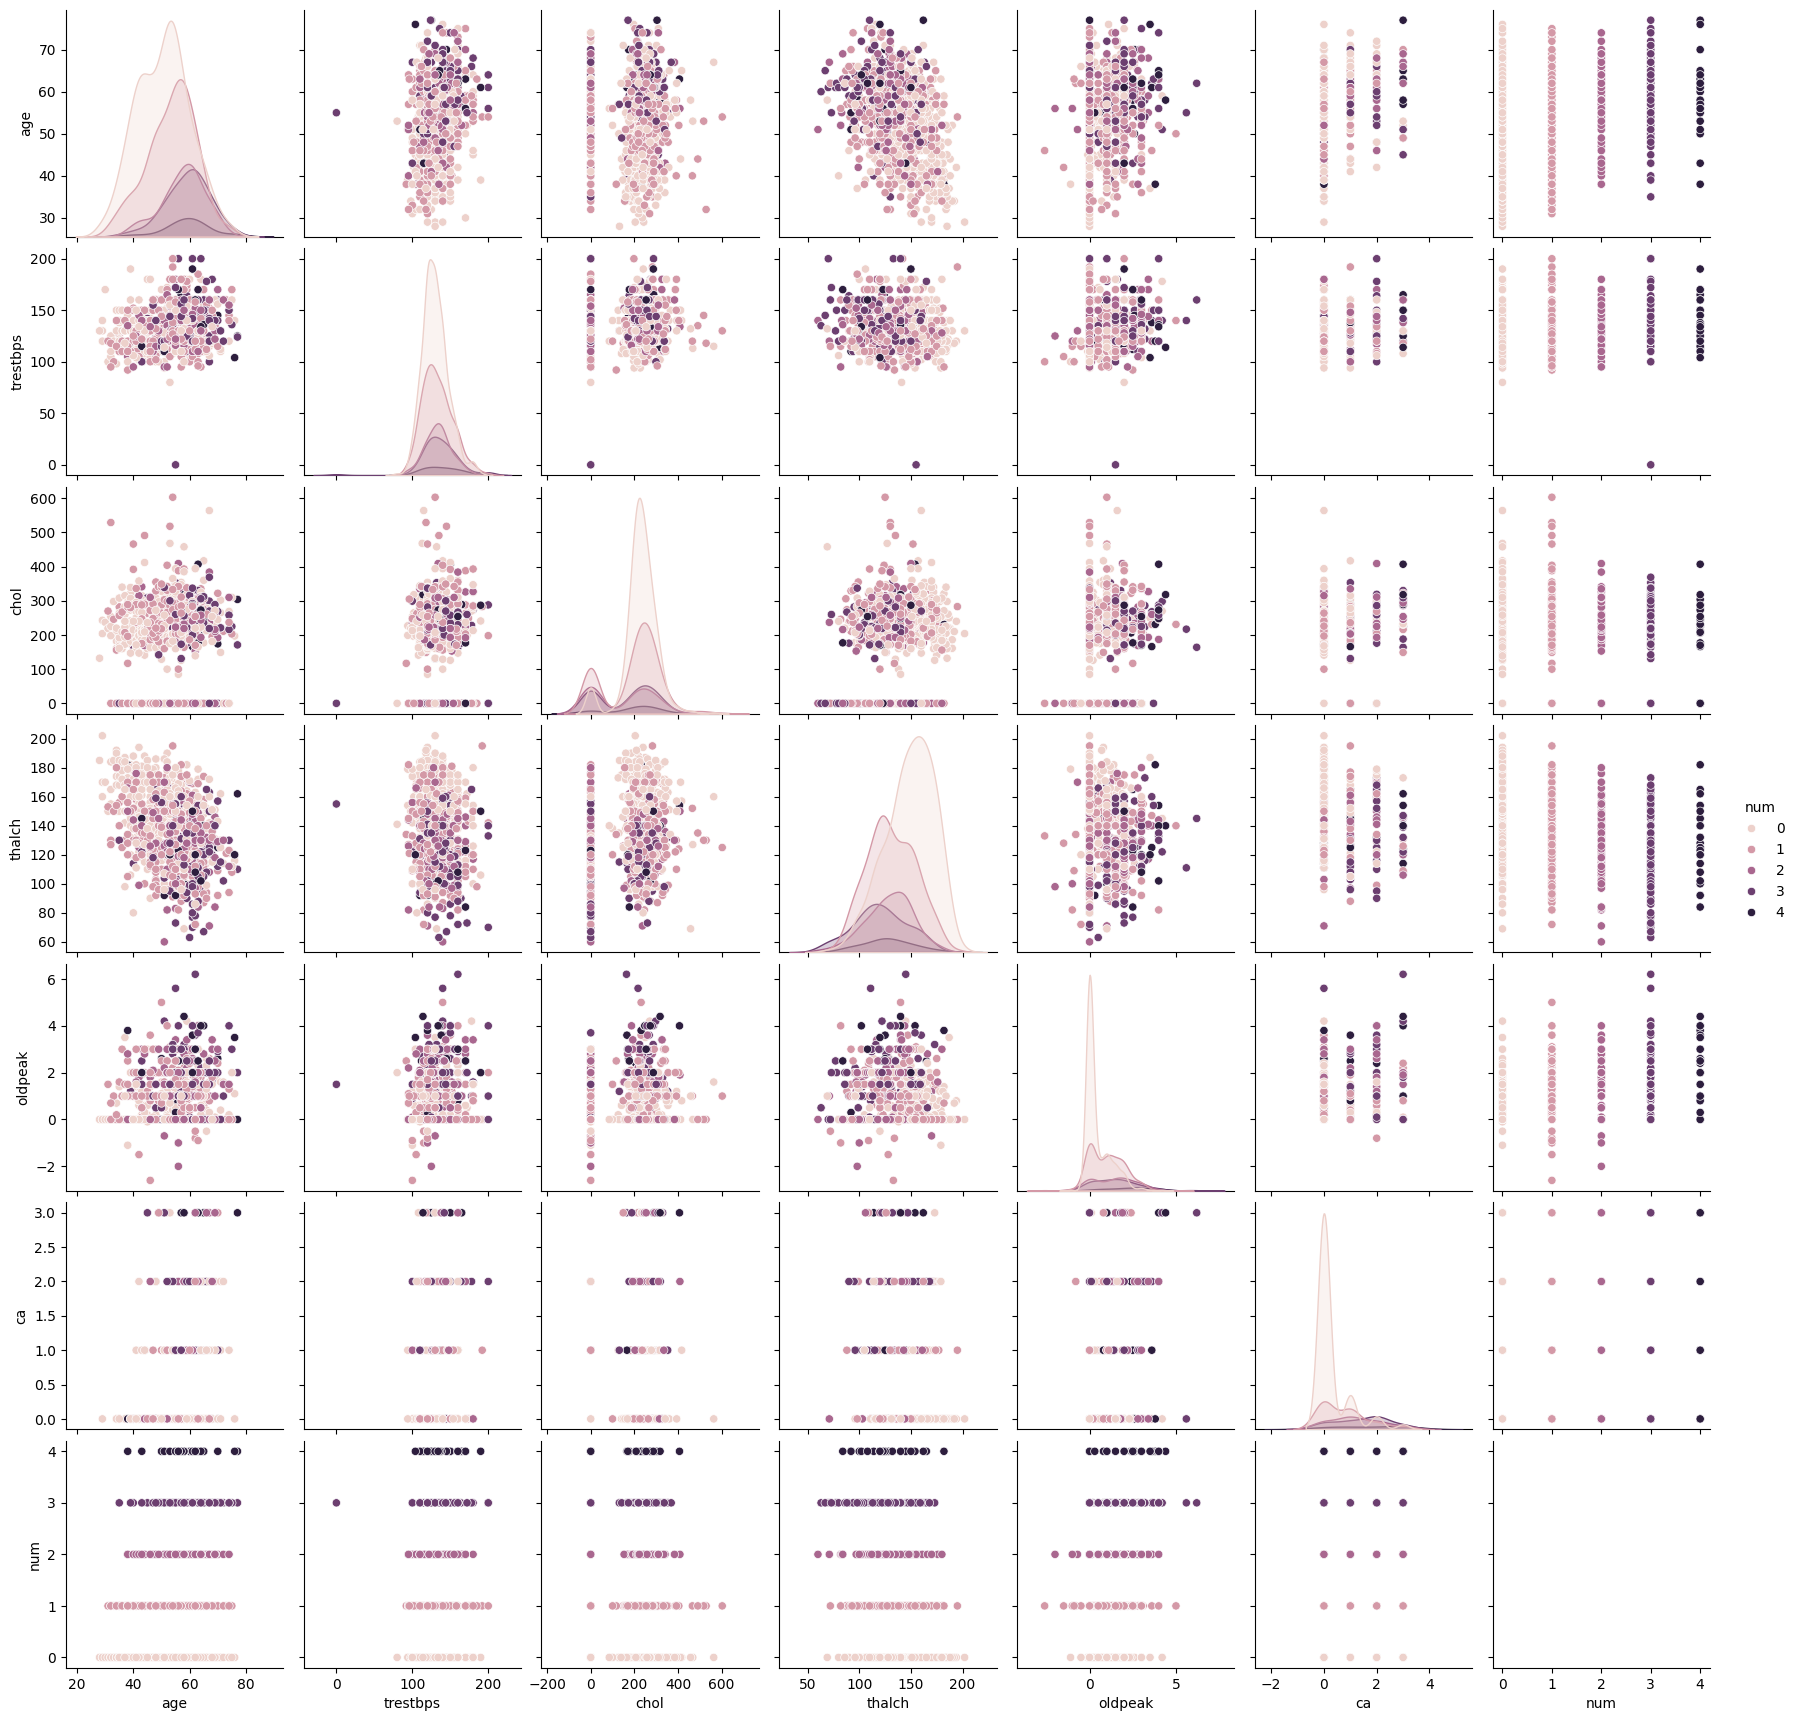

In [165]:
# Pairplot to see how these features separate the classes together
sns.pairplot(df,hue="num",vars=numeric_cols)
plt.show()

In [166]:
df['is_class_4'] = (df['num'] == 4).astype(int)

df.drop(columns=['is_class_4'], inplace=True)


**Features Enginnering**

In [167]:
X=df.drop(columns=["num"])
y=df["num"]

In [168]:
X['risk_score'] = (
    (X['age'] > 55).astype(int) +
    (X['trestbps'] > 140).astype(int) +
    (X['chol'] > 240).astype(int) +
    (X['fbs'] == 1).astype(int) +
    (X['exang'] == 1).astype(int) +
    (X['oldpeak'] > 1.0).astype(int)
)


**Preprocessing**

In [169]:
# 2. Identify column types automatically
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical features: {num_cols}")
print(f"Categorical features: {cat_cols}")


Numerical features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'risk_score']
Categorical features: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [170]:
# defining the pipeline to preprocess the data


num_tranformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ("scaler",StandardScaler())

])

cat_tranformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('num',num_tranformer,num_cols),
    ('cat',cat_tranformer,cat_cols)
])


In [171]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


**Modeling**

In [172]:
# split the data into test and train

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [173]:
import optuna
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score


def objective(trial, X, y, preprocessor):
    model_type = trial.suggest_categorical(
        "model_type", ["xgboost", "Lasso", "randomforest"]
    )

    # 1. Hyperparameter definitions
    if model_type == "randomforest":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 100, 500, step=50),
            max_depth=trial.suggest_int("rf_max_depth", 4, 12),
            min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10),
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
    elif model_type == "xgboost":
        model = xgb.XGBClassifier(
            n_estimators=trial.suggest_int(
                "xgb_n_estimators", 100, 500, step=50
            ),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 8),
            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.1, log=True),
            subsample=trial.suggest_float("xgb_subsample", 0.6, 1.0),
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            device="cuda",
            tree_method="hist",
            n_jobs=-1,
        )
    elif model_type == "Lasso":
        model = LogisticRegression(
            penalty="l1",
            C=trial.suggest_float("lasso_C", 0.01, 10.0, log=True),
            solver="saga",
            multi_class="multinomial",
            max_iter=10000,
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("Invalid model type")

    # 2. Build the unified data-flow pipeline
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            (
                "smote",
                SMOTE(
                    k_neighbors=trial.suggest_int("smote_k", 2, 4),
                    random_state=42,
                ),
            ),
            ("classifier", model),
        ]
    )

    # 3. Use StratifiedKFold to handle uneven class balances across folds
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # FIX: Use n_jobs=1 if running XGBoost on GPU (cuda) to avoid crash/freeze
    cv_jobs = 1 if model_type == "xgboost" else -1

    try:
        # 4. Score using 'f1_macro' to evaluate multi-class balance accurately
        score = cross_val_score(
            pipeline, X, y, cv=cv, scoring="f1_macro", n_jobs=cv_jobs
        )
        return score.mean()

    except Exception as e:
        # Prevents mathematical divergence errors from crashing the Optuna loop
        print(f"Trial {trial.number} failed due to error: {str(e)}")
        return float("-inf")


In [174]:
# create study
study = optuna.create_study(

    direction="maximize",
)
study.optimize(
    lambda trial: objective(trial, X, y, preprocessor),
    n_trials=50,
    n_jobs=1,
)

print(f"Optimization complete. Best Macro F1-Score: {study.best_value:.4f}")


[I 2026-08-24 11:02:51,214] A new study created in memory with name: no-name-20ee8241-b1de-4590-943f-c2dbde74e611
[I 2026-08-24 11:03:27,309] Trial 0 finished with value: 0.38466184198138026 and parameters: {'model_type': 'Lasso', 'lasso_C': 7.930198984211136, 'smote_k': 2}. Best is trial 0 with value: 0.38466184198138026.
[I 2026-08-24 11:03:44,260] Trial 1 finished with value: 0.39685933777294613 and parameters: {'model_type': 'xgboost', 'xgb_n_estimators': 400, 'xgb_max_depth': 7, 'xgb_lr': 0.021290921184400634, 'xgb_subsample': 0.8667961860909974, 'smote_k': 2}. Best is trial 1 with value: 0.39685933777294613.
[I 2026-08-24 11:03:59,212] Trial 2 finished with value: 0.3792665237629906 and parameters: {'model_type': 'xgboost', 'xgb_n_estimators': 350, 'xgb_max_depth': 7, 'xgb_lr': 0.01682457888301958, 'xgb_subsample': 0.8600563110921527, 'smote_k': 4}. Best is trial 1 with value: 0.39685933777294613.
[I 2026-08-24 11:04:03,360] Trial 3 finished with value: 0.3742634726257051 and par

Optimization complete. Best Macro F1-Score: 0.4102


In [185]:
best_params = study.best_trial.params.copy()
best_model_name = best_params.pop('model_type')
smote_k = best_params.pop('smote_k')

if best_model_name == 'randomforest':
    final_model = RandomForestClassifier(
        n_estimators=best_params['rf_n_estimators'],

        max_depth=best_params['rf_max_depth'],
        min_samples_split=best_params['rf_min_samples_split'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )
elif best_model_name == 'xgboost':
    final_model = xgb.XGBClassifier(
        n_estimators=best_params['xgb_n_estimators'],
        max_depth=best_params['xgb_max_depth'],
        learning_rate=best_params['xgb_lr'],
        subsample=best_params['xgb_subsample'],
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist",   # no device="cuda" — drop it, as discussed
        n_jobs=-1,
    )
elif best_model_name == 'Lasso':
    final_model = LogisticRegression(
        penalty="l1",
        C=best_params['lasso_C'],
        solver="saga",
        multi_class="multinomial",
        max_iter=10000,
        random_state=42,
        n_jobs=-1,
    )
else:
    raise ValueError(f"Unexpected model_type: {best_model_name}")

print(f"Best model: {best_model_name}")
print(f"Params: {best_params}")

final_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTETomek(smote=SMOTE(k_neighbors=smote_k, random_state=2), random_state=2
    )),
    ('classifier', final_model)
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Best model: xgboost
Params: {'xgb_n_estimators': 500, 'xgb_max_depth': 8, 'xgb_lr': 0.010019774861875202, 'xgb_subsample': 0.6988713476323553}
[[64  7  3  1  0]
 [15 23  8  7  1]
 [ 2  4 10  8  1]
 [ 2  8  4 11  1]
 [ 0  0  1  2  1]]
0.592391304347826
              precision    recall  f1-score   support

           0       0.77      0.85      0.81        75
           1       0.55      0.43      0.48        54
           2       0.38      0.40      0.39        25
           3       0.38      0.42      0.40        26
           4       0.25      0.25      0.25         4

    accuracy                           0.59       184
   macro avg       0.47      0.47      0.47       184
weighted avg       0.59      0.59      0.59       184



In [186]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(final_pipeline, X, y, cv=skf, scoring='f1_macro')
print(cv_scores, cv_scores.mean(), cv_scores.std())

[0.35679434 0.37489748 0.39444262 0.39843245 0.41922656] 0.3887586912180322 0.021298039813360235
